In [41]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
khajaahmed1_iot_indoor_air_quality_path = kagglehub.dataset_download('khajaahmed1/iot-indoor-air-quality')

print('Data source import complete.')


Using Colab cache for faster access to the 'iot-indoor-air-quality' dataset.
Data source import complete.


# Data Loading

In [42]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/iot-indoor-air-quality/IoT_Indoor_Air_Quality_Dataset.csv


In [43]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khajaahmed1/iot-indoor-air-quality")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'iot-indoor-air-quality' dataset.
Path to dataset files: /kaggle/input/iot-indoor-air-quality


In [44]:
df = pd.read_csv(os.path.join(path, "IoT_Indoor_Air_Quality_Dataset.csv"))

df.head()

,Timestamp,Temperature (?C),Humidity (%),CO2 (ppm),PM2.5 (?g/m?),PM10 (?g/m?),TVOC (ppb),CO (ppm),Light Intensity (lux),Motion Detected,Occupancy Count,Ventilation Status
0,18-02-2024 08:00,21.75,63.11,989.74,31.17,89.66,226.83,2.84,646.86,0.0,49.0,Open
1,18-02-2024 08:05,27.51,68.03,924.59,27.32,44.82,116.76,3.12,845.45,1.0,11.0,Open
2,18-02-2024 08:10,25.32,53.51,604.05,73.84,71.08,56.59,3.59,560.03,1.0,29.0,Closed
3,18-02-2024 08:15,23.99,58.52,692.20,62.94,10.90,228.06,2.66,499.84,1.0,28.0,Closed
4,18-02-2024 08:20,19.56,69.34,533.12,26.56,88.06,267.26,1.76,411.36,1.0,16.0,Closed


# EDA ()raw

In [45]:
df.shape

(97458, 12)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97458 entries, 0 to 97457
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Timestamp              97458 non-null  object 
 1   Temperature (?C)       95509 non-null  float64
 2   Humidity (%)           95509 non-null  float64
 3   CO2 (ppm)              95509 non-null  float64
 4   PM2.5 (?g/m?)          95509 non-null  float64
 5   PM10 (?g/m?)           95509 non-null  float64
 6   TVOC (ppb)             95509 non-null  float64
 7   CO (ppm)               95509 non-null  float64
 8   Light Intensity (lux)  95509 non-null  float64
 9   Motion Detected        95509 non-null  float64
 10  Occupancy Count        95509 non-null  float64
 11  Ventilation Status     95509 non-null  object 
dtypes: float64(10), object(2)
memory usage: 8.9+ MB


In [47]:
df.describe()

,Temperature (?C),Humidity (%),CO2 (ppm),PM2.5 (?g/m?),PM10 (?g/m?),TVOC (ppb),CO (ppm),Light Intensity (lux),Motion Detected,Occupancy Count
count,95509.000000,95509.000000,95509.000000,95509.000000,95509.000000,95509.000000,95509.000000,95509.000000,95509.000000,95509.000000
mean,22.995823,50.043729,700.367803,39.931032,55.074714,274.884291,2.550054,550.435179,0.499775,24.422641
std,2.884487,11.541731,173.453747,20.198692,25.940032,129.801995,1.414674,259.449197,0.500003,14.459129
min,18.000000,30.000000,400.000000,5.000000,10.000000,50.000000,0.100000,100.040000,0.000000,0.000000
25%,20.500000,40.040000,549.710000,22.430000,32.630000,162.740000,1.330000,326.690000,0.000000,12.000000
50%,23.010000,50.060000,700.640000,39.850000,55.300000,273.910000,2.550000,549.690000,0.000000,24.000000
75%,25.500000,60.000000,850.520000,57.430000,77.450000,387.230000,3.780000,774.740000,1.000000,37.000000
max,28.000000,70.000000,999.990000,75.000000,100.000000,500.000000,5.000000,999.990000,1.000000,49.000000


In [48]:
df.isnull().sum()

,0
Timestamp,0
Temperature (?C),1949
Humidity (%),1949
CO2 (ppm),1949
PM2.5 (?g/m?),1949
PM10 (?g/m?),1949
TVOC (ppb),1949
CO (ppm),1949
Light Intensity (lux),1949
Motion Detected,1949


In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df['Timestamp'].min(), df['Timestamp'].max()

('01-01-2025 00:00', '31-12-2024 23:55')

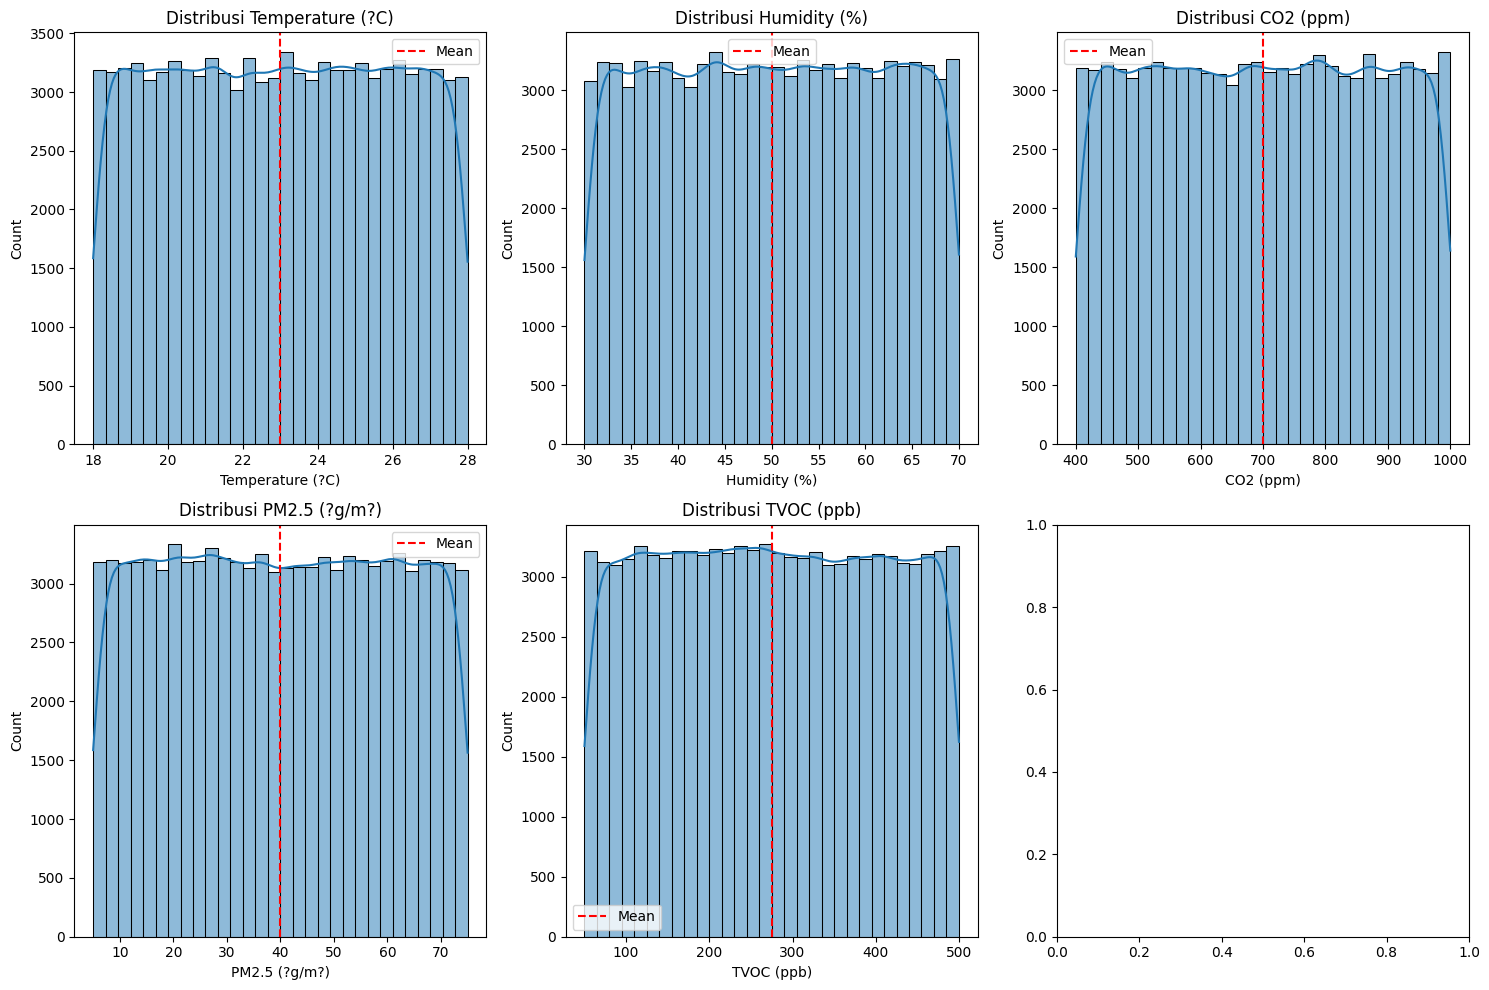

In [51]:
key_numeric = ['Temperature (?C)', 'Humidity (%)', 'CO2 (ppm)', 'PM2.5 (?g/m?)', 'TVOC (ppb)']
key_categorical = ['Ventilation Status']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(key_numeric):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], bins=30)
    axes[idx].set_title(f'Distribusi {col}')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [52]:
# Hitung skewness (setelah load df)
key_numeric = ['Temperature (?C)', 'Humidity (%)', 'CO2 (ppm)', 'PM2.5 (?g/m?)', 'TVOC (ppb)']
skew_df = pd.DataFrame({'Feature': key_numeric, 'Skewness': df[key_numeric].skew()})
print(skew_df)
# Skew >0.5 = skewed right; < -0.5 left; ~0 normal.

                           Feature  Skewness
Temperature (?C)  Temperature (?C) -0.001566
Humidity (%)          Humidity (%) -0.003501
CO2 (ppm)                CO2 (ppm) -0.001706
PM2.5 (?g/m?)        PM2.5 (?g/m?)  0.005212
TVOC (ppb)              TVOC (ppb)  0.007301


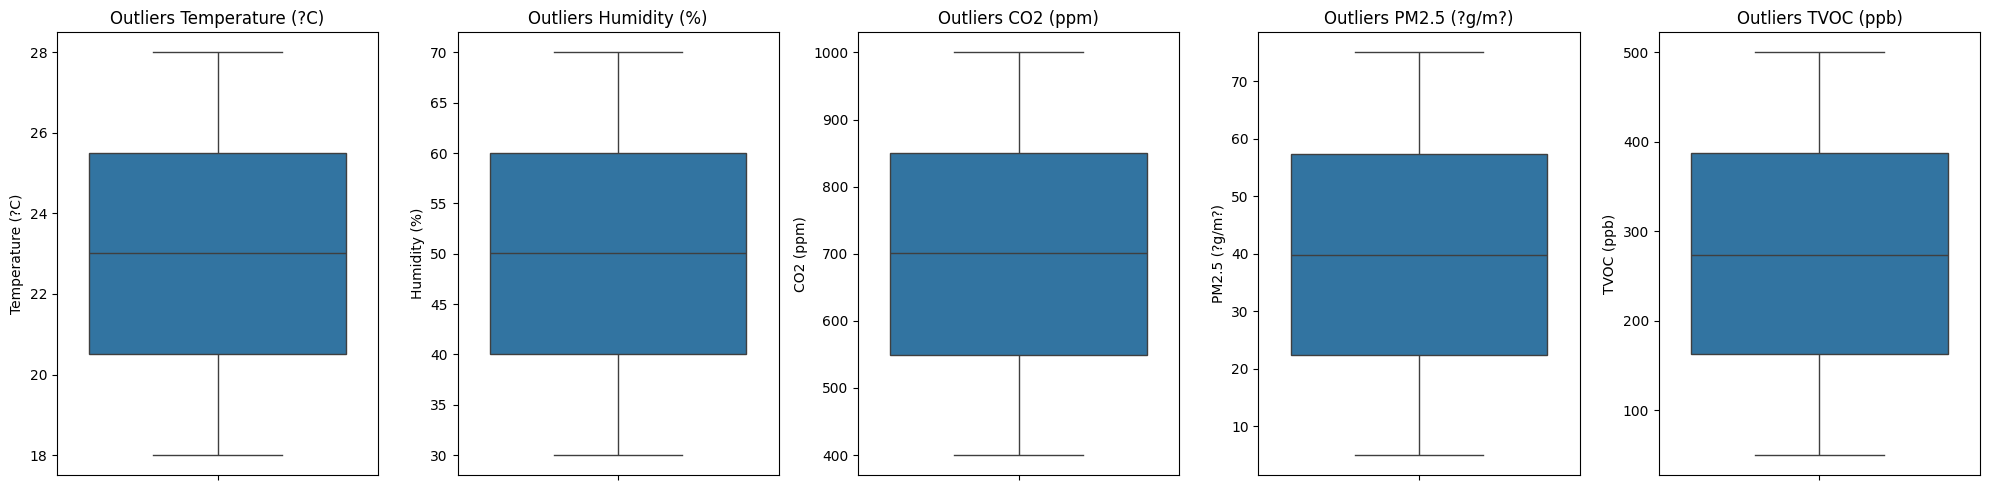

In [53]:
key_numeric = ['Temperature (?C)', 'Humidity (%)', 'CO2 (ppm)', 'PM2.5 (?g/m?)', 'TVOC (ppb)']
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for idx, current_col_name in enumerate(key_numeric):
    if idx < len(axes):
        sns.boxplot(data=df, y=current_col_name, ax=axes[idx])
        axes[idx].set_title(f'Outliers {current_col_name}')

plt.tight_layout()
plt.show()

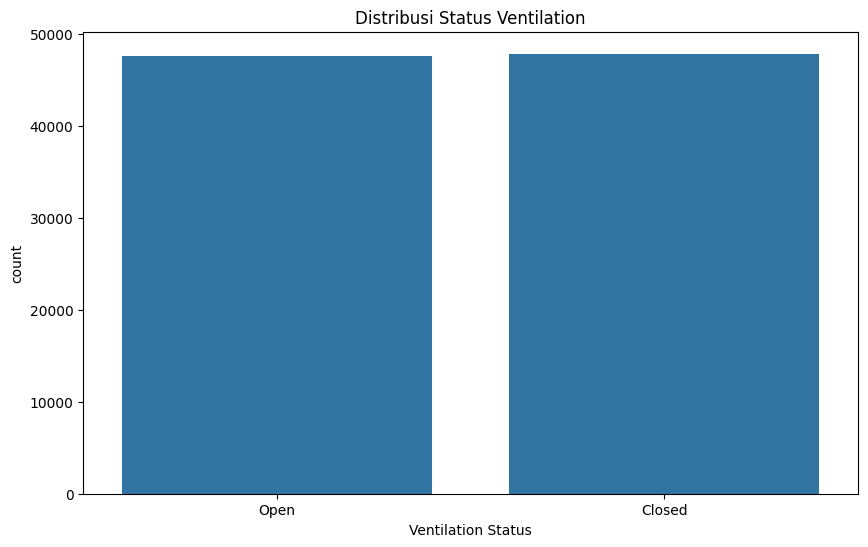

Ventilation Status
Closed    47886
Open      47623
Name: count, dtype: int64


In [54]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Ventilation Status')
plt.title('Distribusi Status Ventilation')
plt.show()
print(df['Ventilation Status'].value_counts())

**BIVARIATE ANALYSIS**



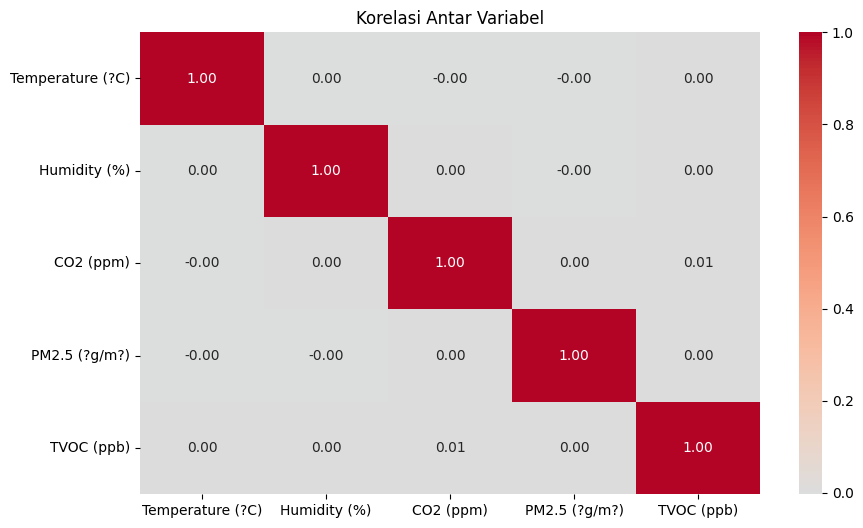

,Temperature (?C),Humidity (%),CO2 (ppm),PM2.5 (?g/m?),TVOC (ppb)
Temperature (?C),1.000000,0.000035,-0.003031,-0.000430,0.002798
Humidity (%),0.000035,1.000000,0.003823,-0.001051,0.004618
CO2 (ppm),-0.003031,0.003823,1.000000,0.001489,0.005848
PM2.5 (?g/m?),-0.000430,-0.001051,0.001489,1.000000,0.003467
TVOC (ppb),0.002798,0.004618,0.005848,0.003467,1.000000


In [55]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[key_numeric].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korelasi Antar Variabel')
plt.show()
df[key_numeric].corr()

In [56]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

df_eda = df.copy()
df_eda = df_eda.ffill()  # Atau .fillna(method='ffill')

key_numeric = ['Temperature (?C)', 'Humidity (%)', 'CO2 (ppm)', 'PM2.5 (?g/m?)', 'TVOC (ppb)']

# Fixed: Exclude target dari features
features = [col for col in key_numeric if col != 'PM2.5 (?g/m?)']  # Buat target PM2.5
X = df_eda[features]
y = df_eda['PM2.5 (?g/m?)']
mi_scores = mutual_info_regression(X, y)
mi_df = pd.DataFrame({'Feature': features, 'MI Score': mi_scores}).sort_values('MI Score', ascending=False)
print(mi_df)

            Feature  MI Score
3        TVOC (ppb)  0.002889
1      Humidity (%)  0.002095
0  Temperature (?C)  0.000000
2         CO2 (ppm)  0.000000


**Time Series**

In [57]:
df_timeseries = df_eda.copy()
df_timeseries['Timestamp'] = pd.to_datetime(df_timeseries['Timestamp'], dayfirst=True)
df_timeseries = df_timeseries.set_index('Timestamp')
df_timeseries.head()

,Temperature (?C),Humidity (%),CO2 (ppm),PM2.5 (?g/m?),PM10 (?g/m?),TVOC (ppb),CO (ppm),Light Intensity (lux),Motion Detected,Occupancy Count,Ventilation Status
Timestamp,,,,,,,,,,,
2024-02-18 08:00:00,21.75,63.11,989.74,31.17,89.66,226.83,2.84,646.86,0.0,49.0,Open
2024-02-18 08:05:00,27.51,68.03,924.59,27.32,44.82,116.76,3.12,845.45,1.0,11.0,Open
2024-02-18 08:10:00,25.32,53.51,604.05,73.84,71.08,56.59,3.59,560.03,1.0,29.0,Closed
2024-02-18 08:15:00,23.99,58.52,692.20,62.94,10.90,228.06,2.66,499.84,1.0,28.0,Closed
2024-02-18 08:20:00,19.56,69.34,533.12,26.56,88.06,267.26,1.76,411.36,1.0,16.0,Closed


In [58]:
numeric_cols = df_timeseries.select_dtypes(include=np.number).columns
df_hourly = df_timeseries[numeric_cols].resample('H').mean()
print("DataFrame resampled to hourly frequency:")
df_hourly.head()

DataFrame resampled to hourly frequency:


/tmp/ipython-input-4043757960.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_timeseries[numeric_cols].resample('H').mean()


,Temperature (?C),Humidity (%),CO2 (ppm),PM2.5 (?g/m?),PM10 (?g/m?),TVOC (ppb),CO (ppm),Light Intensity (lux),Motion Detected,Occupancy Count
Timestamp,,,,,,,,,,
2024-02-18 08:00:00,23.160833,56.132500,733.094167,35.425000,57.172500,246.992500,3.070000,606.590000,0.750000,22.166667
2024-02-18 09:00:00,21.641667,45.937500,624.723333,38.105833,52.264167,312.658333,3.158333,662.675833,0.750000,21.500000
2024-02-18 10:00:00,23.133333,47.936667,781.359167,37.710000,56.764167,260.671667,2.669167,484.709167,0.416667,28.083333
2024-02-18 11:00:00,22.034167,50.466667,701.753333,45.315000,58.182500,290.242500,2.010000,488.063333,0.333333,17.666667
2024-02-18 12:00:00,23.404167,49.495833,702.664167,33.010000,55.492500,299.838333,2.657500,474.983333,0.500000,26.250000


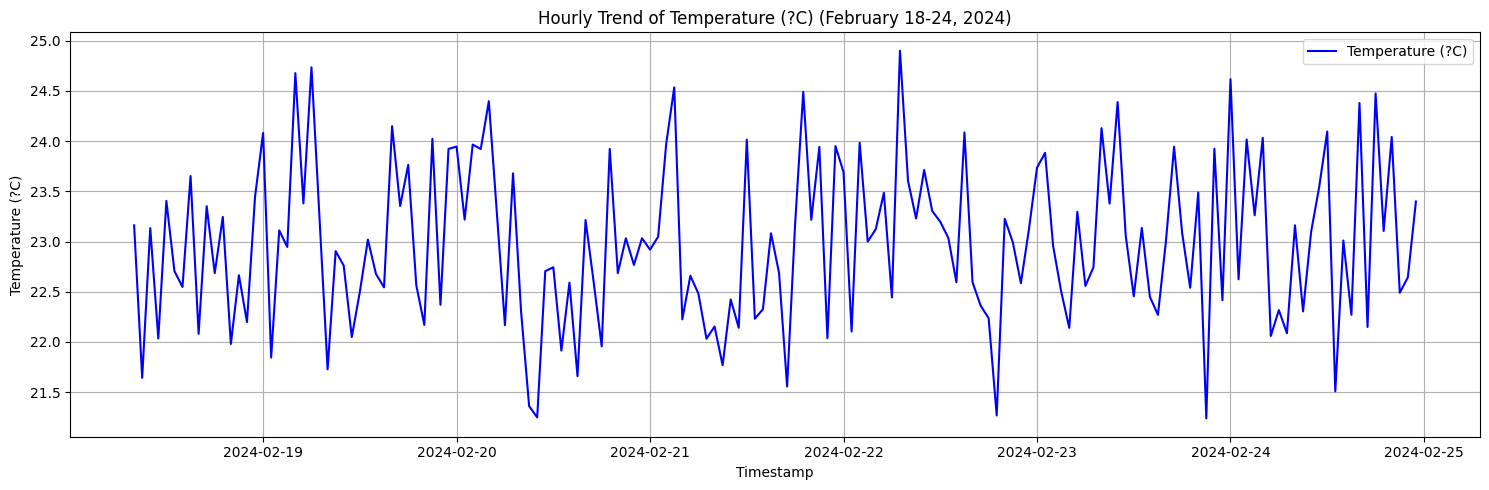

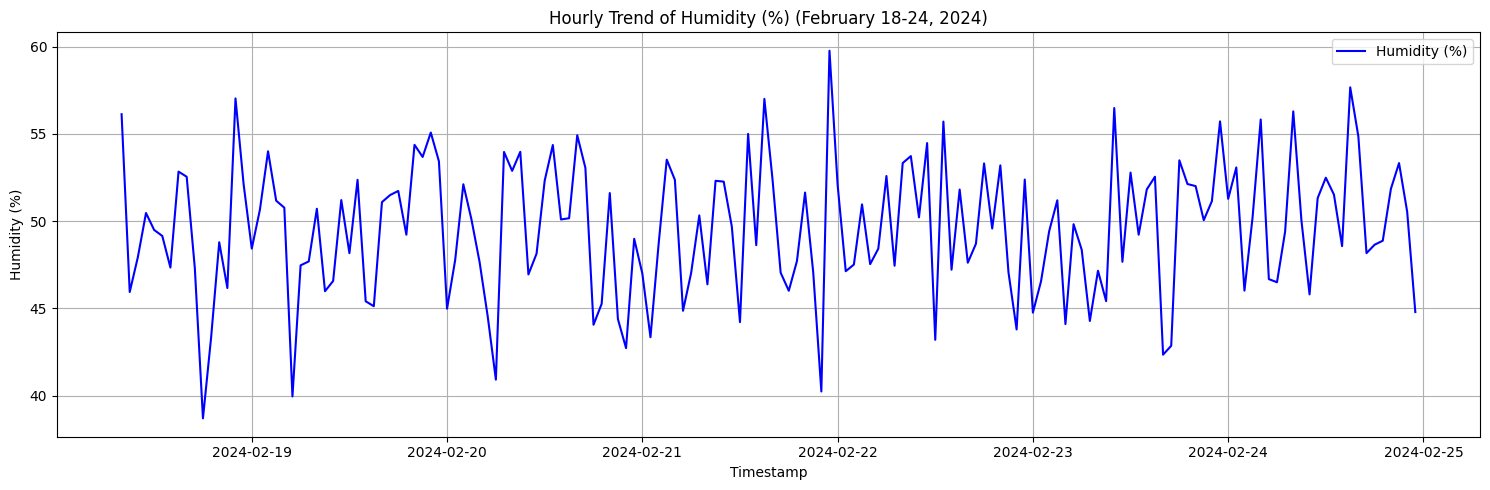

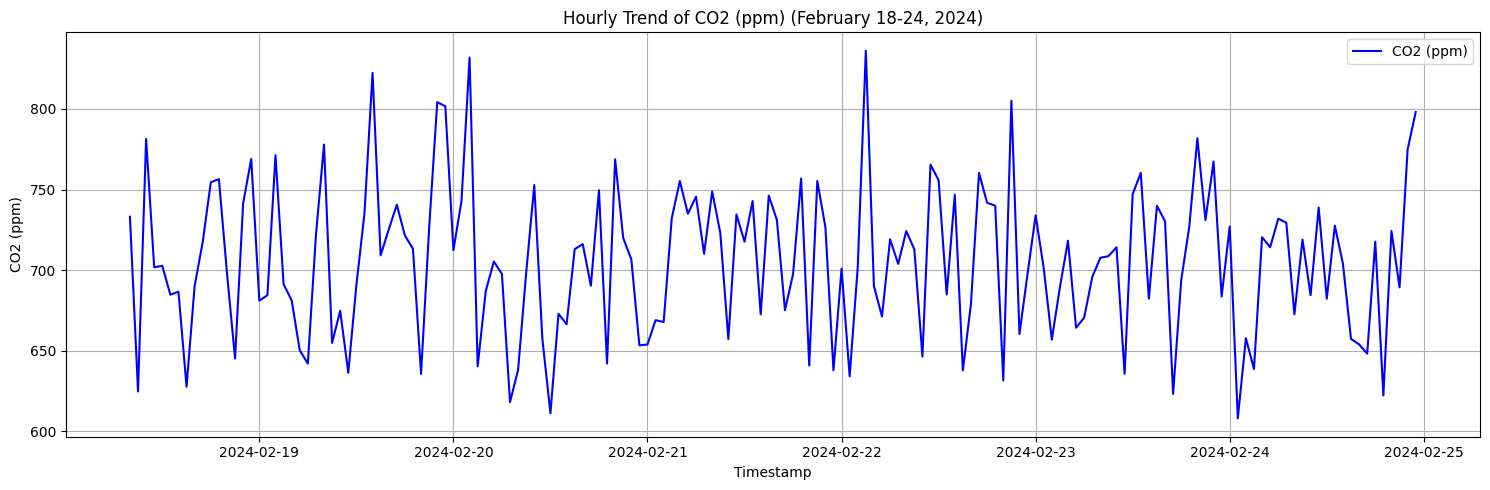

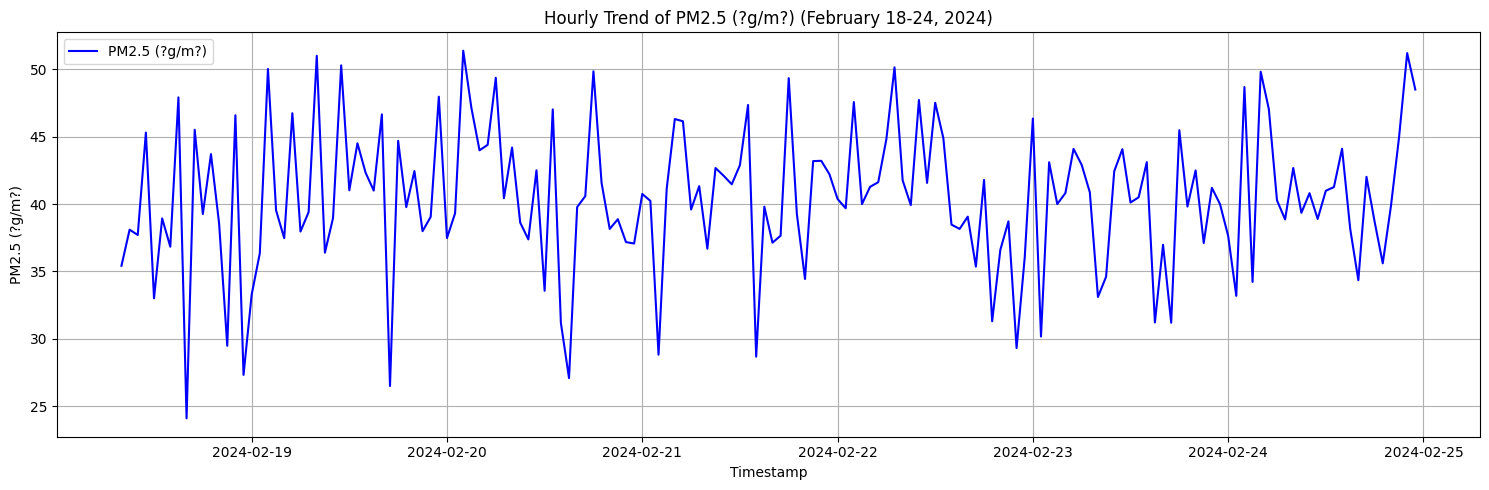

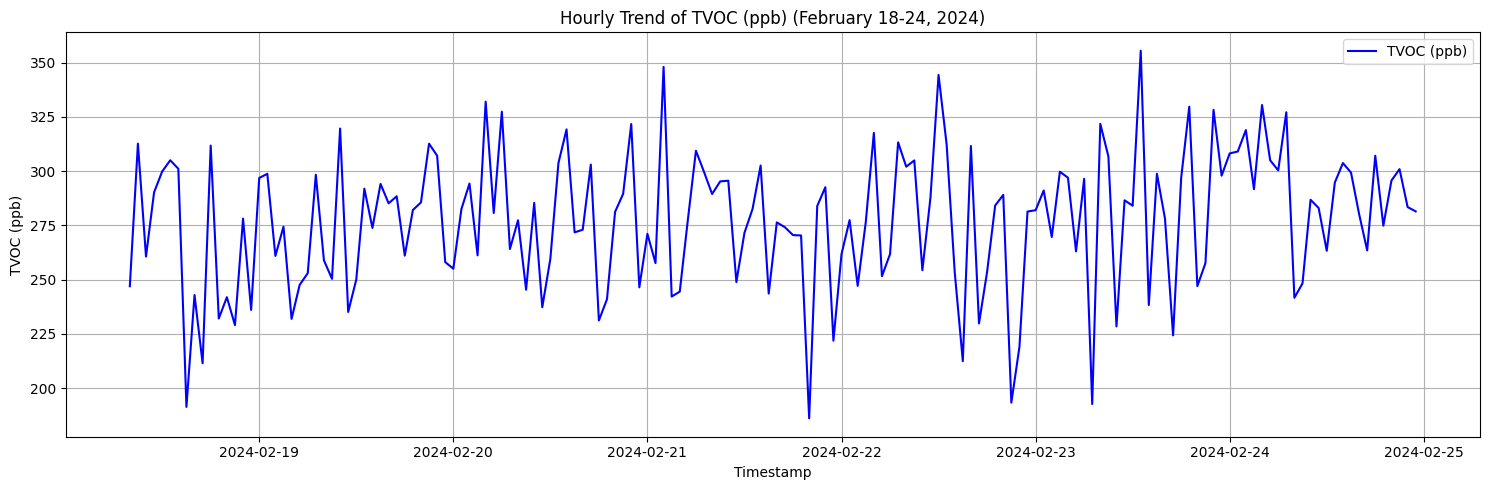

Separate hourly time series plots for key numeric columns for February 18-24, 2024 displayed.


In [59]:
# Filter df_hourly for a single week, e.g., the first week of February 2024
df_hourly_week = df_hourly.loc['2024-02-18':'2024-02-24'] # Example for one week

key_numeric_for_plot = ['Temperature (?C)', 'Humidity (%)', 'CO2 (ppm)', 'PM2.5 (?g/m?)', 'TVOC (ppb)']

for col in key_numeric_for_plot:
    plt.figure(figsize=(15, 5)) # Create a new figure for each plot
    plt.plot(df_hourly_week.index, df_hourly_week[col], label=col, color='blue')
    plt.title(f'Hourly Trend of {col} (February 18-24, 2024)')
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
print("Separate hourly time series plots for key numeric columns for February 18-24, 2024 displayed.")

In [60]:
numeric_cols_day_month = df_timeseries.select_dtypes(include=np.number).columns
df_day = df_timeseries[numeric_cols_day_month].resample('D').mean()
df_day.head()

,Temperature (?C),Humidity (%),CO2 (ppm),PM2.5 (?g/m?),PM10 (?g/m?),TVOC (ppb),CO (ppm),Light Intensity (lux),Motion Detected,Occupancy Count
Timestamp,,,,,,,,,,
2024-02-18,22.745573,49.078958,707.185677,37.989740,52.981250,261.968906,2.599375,534.520417,0.520833,23.208333
2024-02-19,23.103715,49.824444,712.182014,41.313681,55.322778,275.667153,2.444236,526.381979,0.486111,26.041667
2024-02-20,22.845694,48.996563,695.524201,40.762292,54.618090,278.510694,2.594792,547.951875,0.434028,25.253472
2024-02-21,22.877917,49.354062,709.710000,40.523507,56.845243,273.151806,2.576458,579.015625,0.517361,23.246528
2024-02-22,23.078090,49.958993,710.300625,40.577396,55.972257,272.525868,2.637361,536.210729,0.437500,22.958333


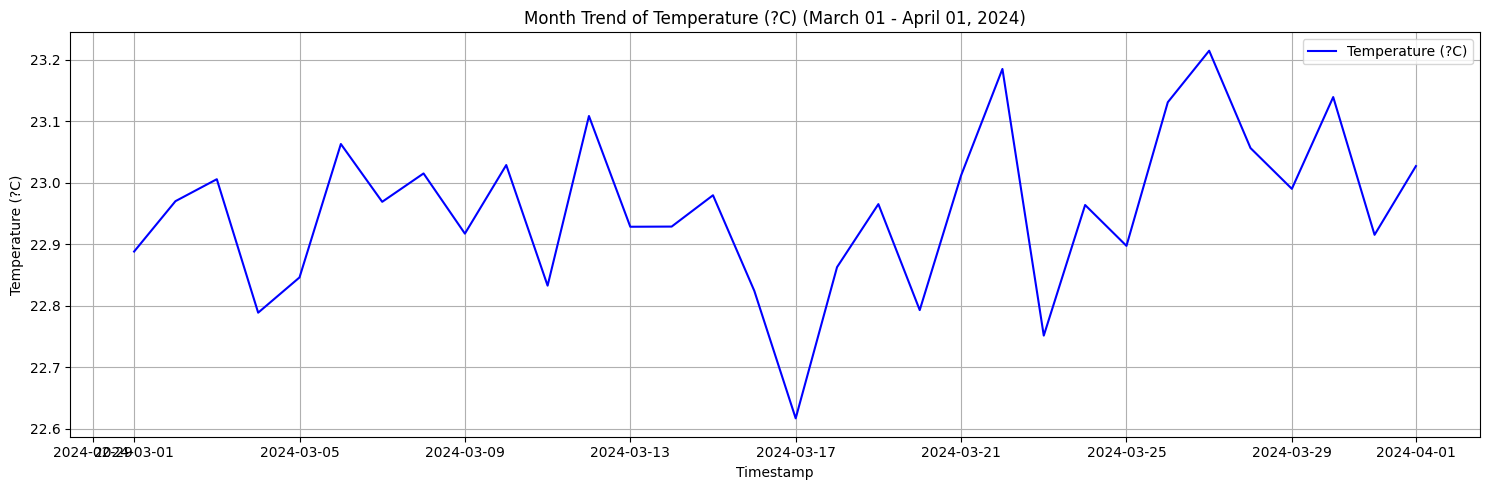

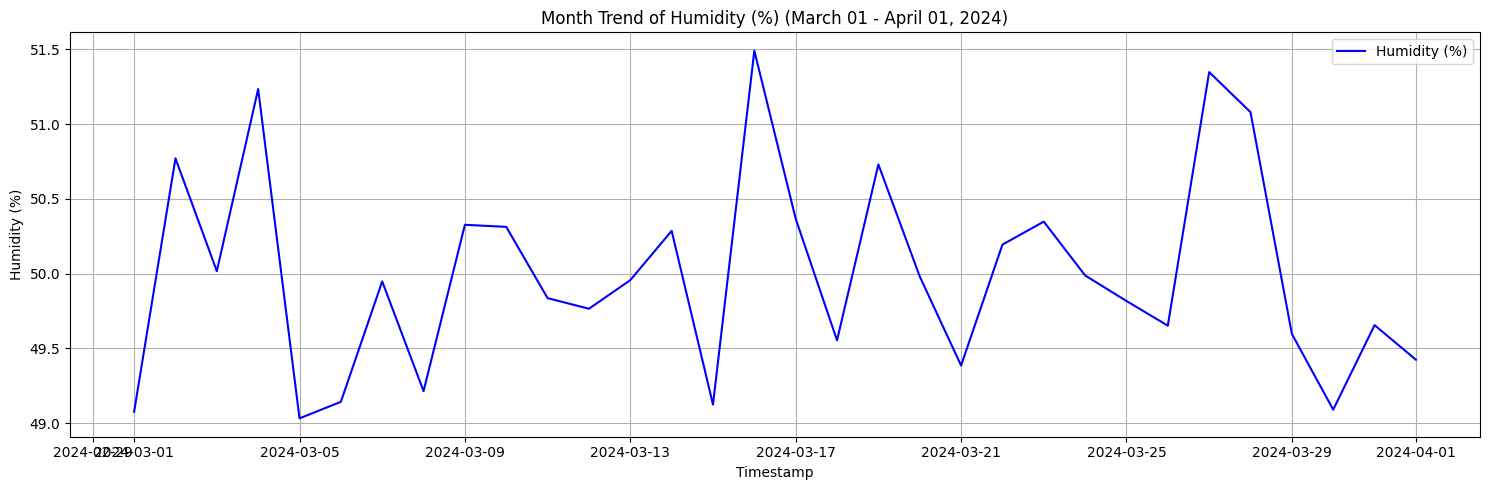

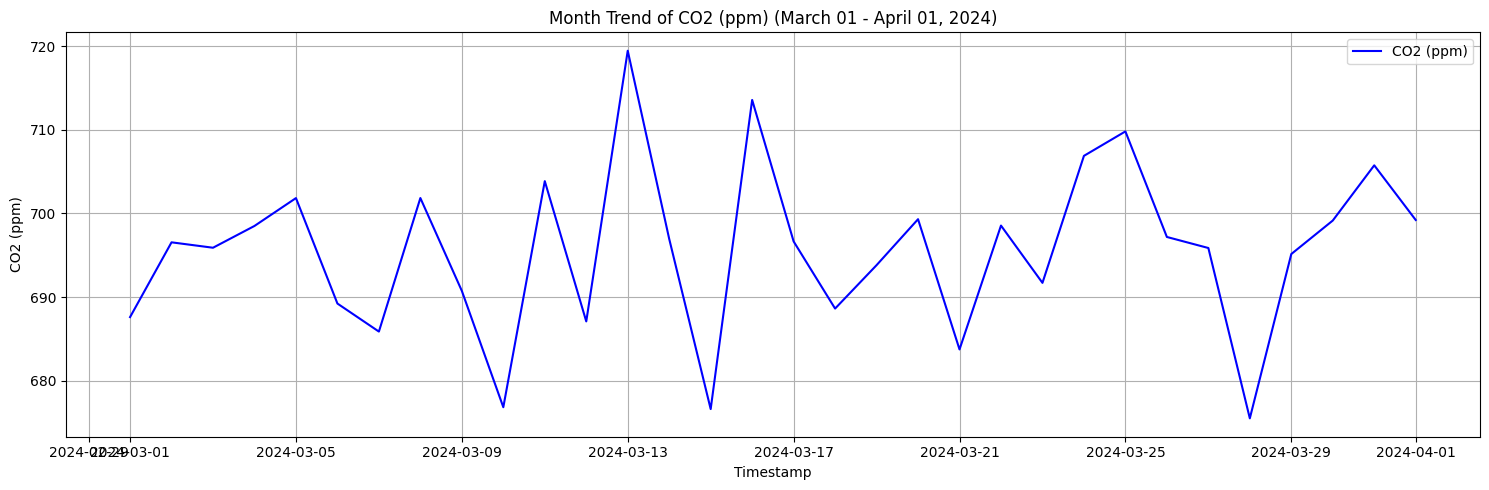

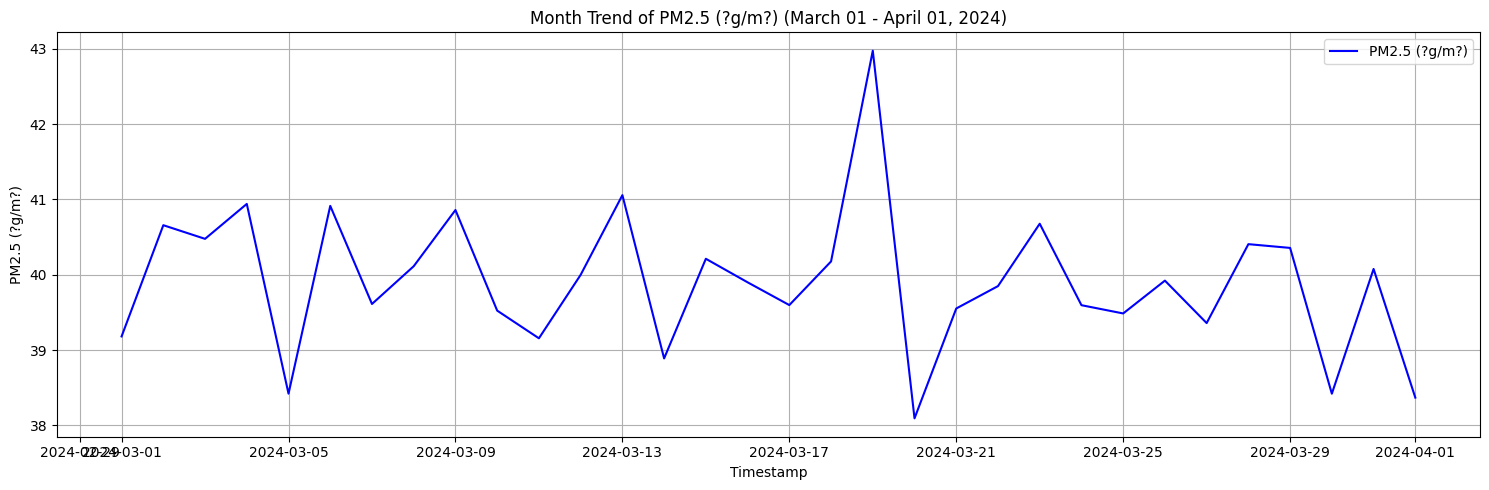

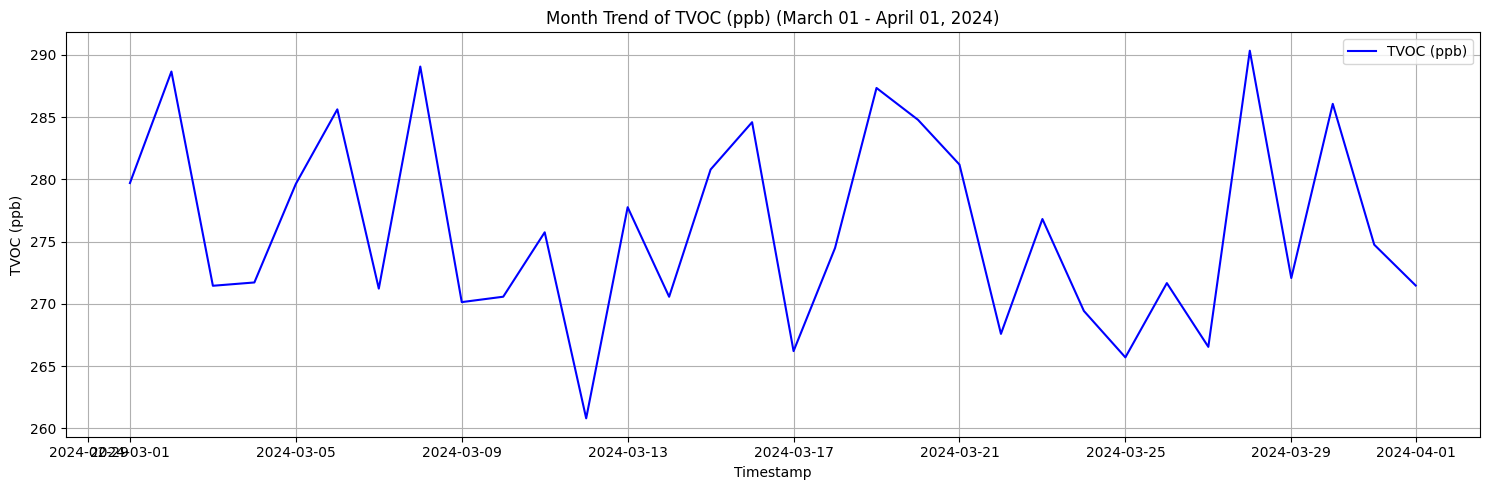

Separate hourly time series plots for key numeric columns for February 18-24, 2024 displayed.


In [61]:
df_day_month = df_day.loc['2024-03-01':'2024-04-01']

key_numeric_for_plot = ['Temperature (?C)', 'Humidity (%)', 'CO2 (ppm)', 'PM2.5 (?g/m?)', 'TVOC (ppb)']

for col in key_numeric_for_plot:
    plt.figure(figsize=(15, 5)) # Create a new figure for each plot
    plt.plot(df_day_month.index, df_day_month[col], label=col, color='blue')
    plt.title(f'Month Trend of {col} (March 01 - April 01, 2024)')
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
print("Separate hourly time series plots for key numeric columns for February 18-24, 2024 displayed.")

In [62]:
numeric_cols_month_year = df_timeseries.select_dtypes(include=np.number).columns
df_month = df_timeseries[numeric_cols_month_year].resample('M').mean()
df_month.head()

/tmp/ipython-input-2934060991.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_month = df_timeseries[numeric_cols_month_year].resample('M').mean()


,Temperature (?C),Humidity (%),CO2 (ppm),PM2.5 (?g/m?),PM10 (?g/m?),TVOC (ppb),CO (ppm),Light Intensity (lux),Motion Detected,Occupancy Count
Timestamp,,,,,,,,,,
2024-02-29,22.994684,49.788135,705.002188,39.912891,55.486133,276.389606,2.541257,549.945723,0.500000,24.336263
2024-03-31,22.954675,50.010845,695.486831,39.950185,54.682046,276.224227,2.545092,557.589760,0.499888,24.386537
2024-04-30,23.038157,50.098966,698.728852,39.970433,55.089576,273.312965,2.539962,551.521066,0.505671,24.319213
2024-05-31,22.999226,49.682371,703.889335,39.746920,55.365281,274.313907,2.537370,550.340349,0.495184,24.346326
2024-06-30,22.981922,50.138916,703.432919,40.169774,54.889420,273.789331,2.537772,549.063841,0.504282,24.459144


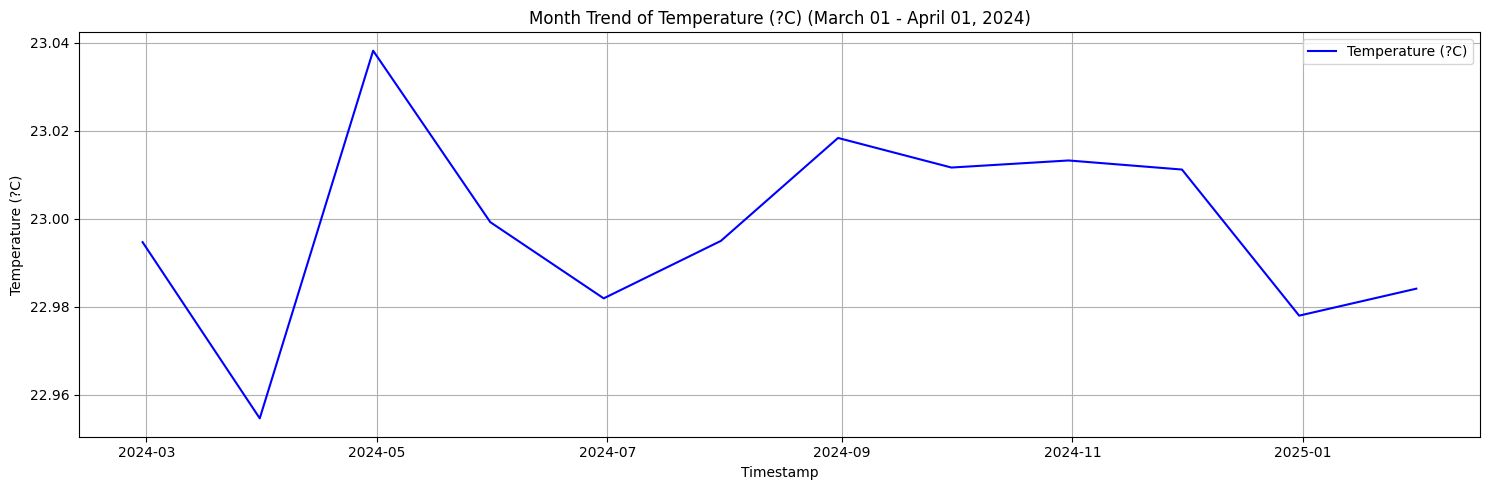

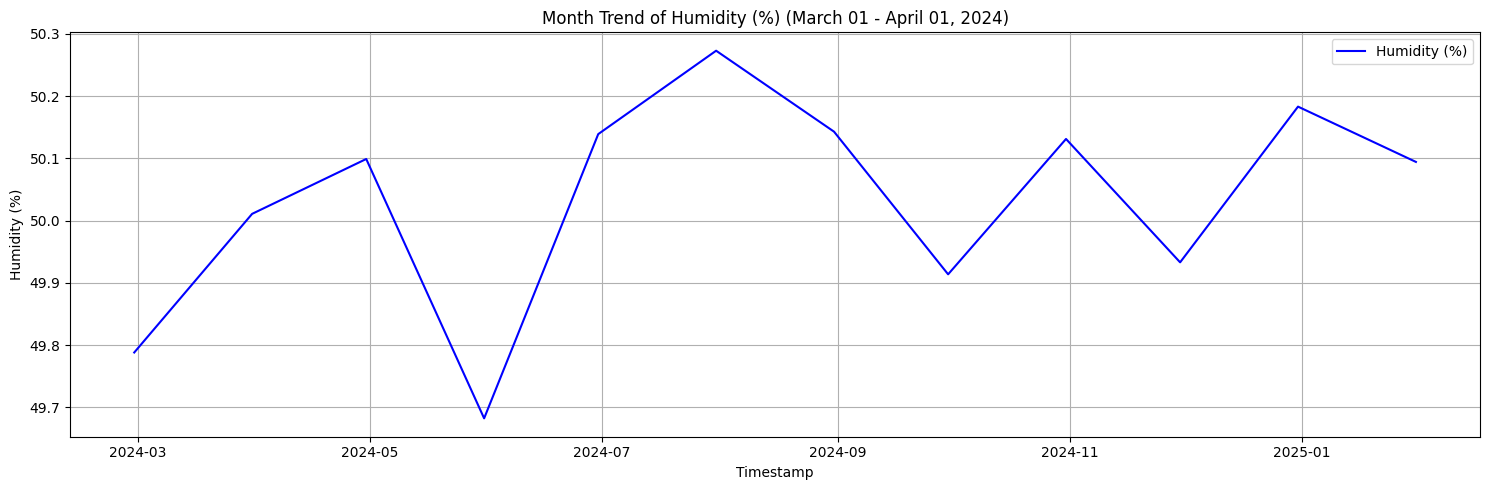

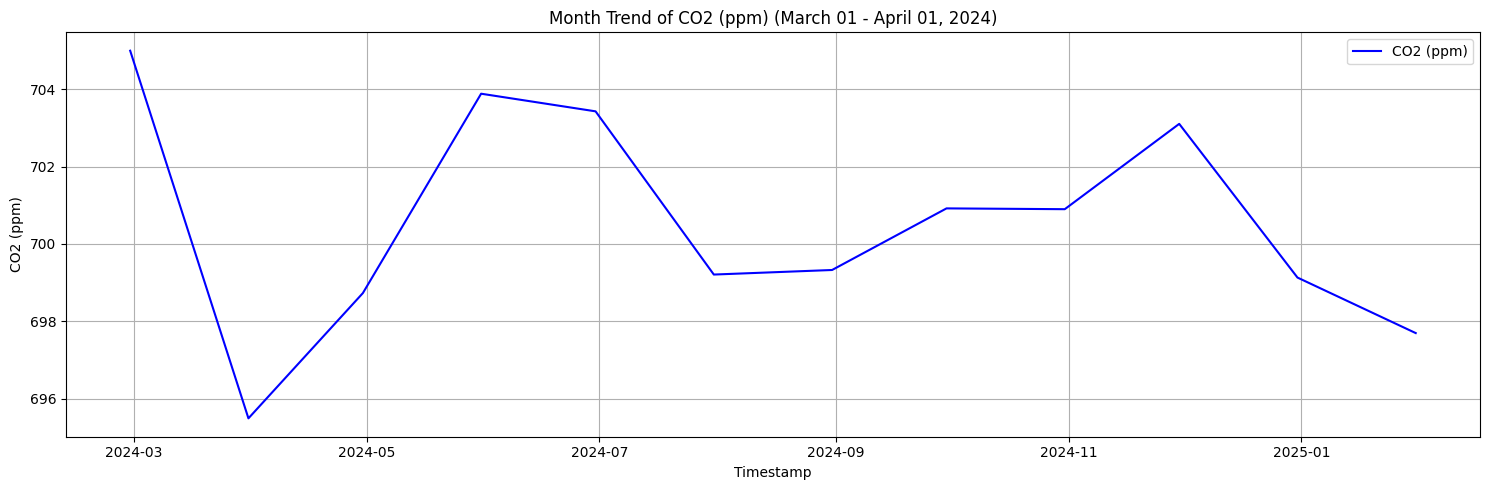

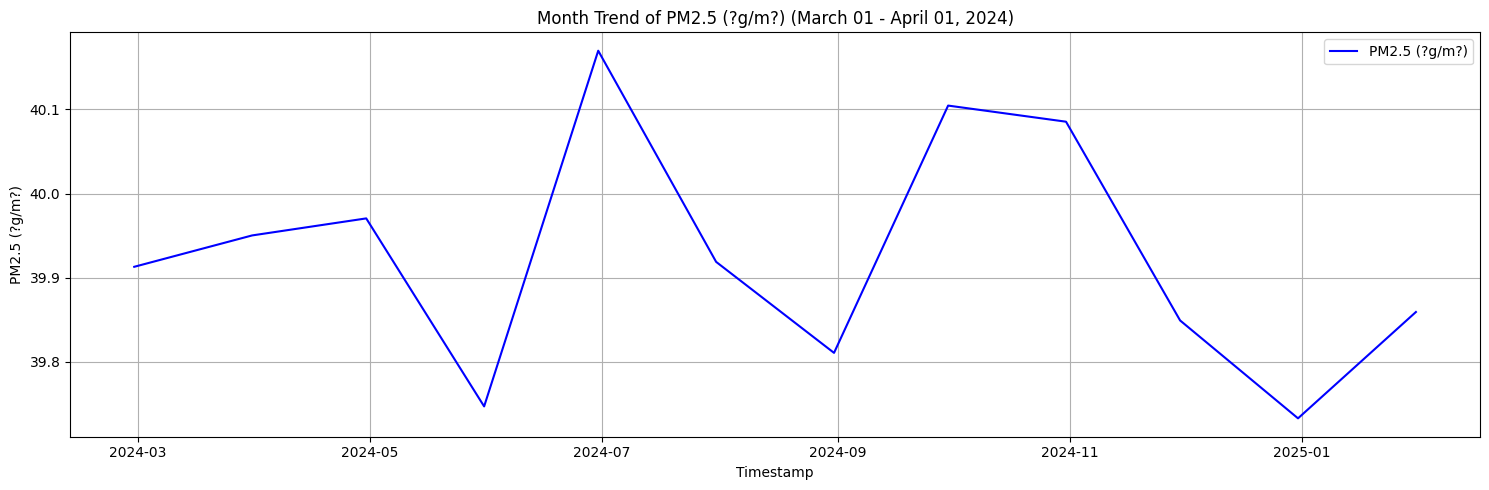

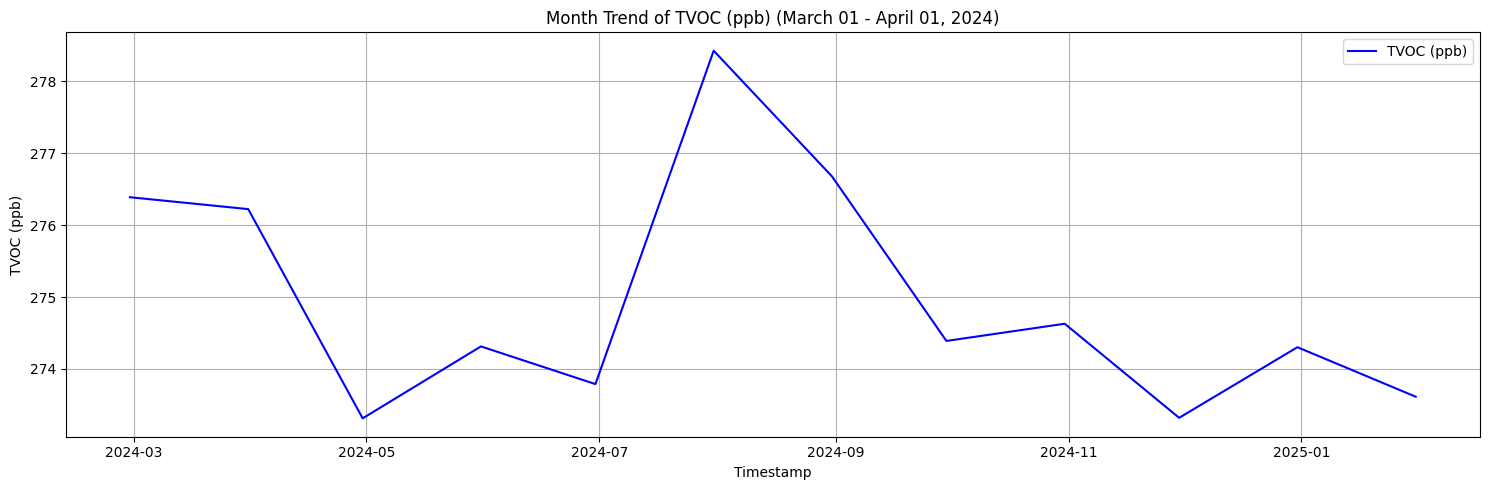

Separate hourly time series plots for key numeric columns for February 18-24, 2024 displayed.


In [63]:
for col in key_numeric_for_plot:
    plt.figure(figsize=(15, 5)) # Create a new figure for each plot
    plt.plot(df_month.index, df_month[col], label=col, color='blue')
    plt.title(f'Month Trend of {col} (March 01 - April 01, 2024)')
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
print("Separate hourly time series plots for key numeric columns for February 18-24, 2024 displayed.")

# **Dokumentasi EDA**

1. **Tujuan EDA**
  - Sumber: Dataset Kaggle IoT Indoor Quality (97k, timestamped interval 5 menit, Jan-Des 2024).
  - Key Parameter: 5 Parameter utama (PM2.5, CO2, TVOC, Temp, Humidity) + (ventilatioan status)
  - Kualitas Data: Terdapat Missing value pada beberapa kolom.

2. **Analisis Univariate**
  - PM2.5: Simetris
  - CO2: Simetris
  - TVOC: Simetris
  - Temp: Simetris
  - Humidity: Simetris

3. **Analisis Bivariate & Dependency**
  - Heatmap Corr: Rendah linear Korelasi
  - MI Scores: Korelasi Rendah

**Next Steps**
1. **Preprocessing**:
  - Mengisi kolom kolom yang kosong,
  - Mengencoding kolom kategori (Ventilation Status)
  - Normalisasi Menggunakan StandardScaler
  - Klasifikasi Zona (Healty/Moderate/Critical)


2.  **Feature Engineering**:
  - Melakukan normalisasi
  - Bikin fitur baru dari EDA (e.g., lag CO2 untuk trends, spike PM2.5 untuk deteksi event, interaksi TVOC*PM2.5 dari MI lemah).

3. **Feature Selection (FS)**:
   - Pilih fitur relevan (RF importance atau SelectKBest dengan MI, drop irrelevant seperti Light Intensity).

4. **Model Building**:
   - RF untuk klasifikasi zona (target Zone_encoded).
   - LSTM untuk prediksi PM2.5 next (time-series).

5. **Evaluasi**:
   - Train/test split, cross-val, metrics (F1/accuracy RF, MSE LSTM).
   - Confusion matrix & feature importance.

6. **Deployment & Iterasi**:
   - Convert ke TensorFlow Lite (ringan buat Edge AI).
   - Test rekomendasi (e.g., "Buka ventilasi" pas Critical).
   - Retrain dengan data baru (e.g., tambah AQI eksternal).

# Preprocessing & Feature Engineering

In [64]:
df.columns = [
    'Timestamp', 'Temperature', 'Humidity', 'CO2', 
    'PM2_5', 'PM10', 'TVOC', 'CO', 'Light', 
    'Motion', 'Occupancy', 'Ventilation Status'
]

In [65]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d-%m-%Y %H:%M')
df = df.sort_values('Timestamp').set_index('Timestamp')

In [66]:
df = df.interpolate(method='time').fillna(method='bfill')

/tmp/ipython-input-1322954692.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='time').fillna(method='bfill')
/tmp/ipython-input-1322954692.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='time').fillna(method='bfill')


In [67]:
print("Preview Data Bersih:")
print(df.head())

Preview Data Bersih:
                     Temperature  Humidity     CO2  PM2_5   PM10    TVOC  \
Timestamp                                                                  
2024-02-18 08:00:00        21.75     63.11  989.74  31.17  89.66  226.83   
2024-02-18 08:05:00        27.51     68.03  924.59  27.32  44.82  116.76   
2024-02-18 08:10:00        25.32     53.51  604.05  73.84  71.08   56.59   
2024-02-18 08:15:00        23.99     58.52  692.20  62.94  10.90  228.06   
2024-02-18 08:20:00        19.56     69.34  533.12  26.56  88.06  267.26   

                       CO   Light  Motion  Occupancy Ventilation Status  
Timestamp                                                                
2024-02-18 08:00:00  2.84  646.86     0.0       49.0               Open  
2024-02-18 08:05:00  3.12  845.45     1.0       11.0               Open  
2024-02-18 08:10:00  3.59  560.03     1.0       29.0             Closed  
2024-02-18 08:15:00  2.66  499.84     1.0       28.0             Closed  
20

In [68]:
def define_zone(row):
    if row['PM2_5'] > 55 or row['CO2'] > 1500 or row['TVOC'] > 1000 or row['CO'] > 10 or row['PM10'] > 100:
        return 'Critical'
    elif row['PM2_5'] > 30 or row['CO2'] > 1000 or row['TVOC'] > 400 or row['CO'] > 5 or row['PM10'] > 50:
        return 'Moderate'
    else:
        return 'Healthy'

In [69]:
df['Zone'] = df.apply(define_zone, axis=1)

In [70]:
le_vent = LabelEncoder()
df['Ventilation_Encoded'] = le_vent.fit_transform(df['Ventilation Status'])

In [71]:
le_zone = LabelEncoder()
df['Zone_Encoded'] = le_zone.fit_transform(df['Zone'])

In [72]:
print("Distribusi Zona:")
print(df['Zone'].value_counts())

Distribusi Zona:
Zone
Moderate    57939
Critical    27455
Healthy     12064
Name: count, dtype: int64


In [73]:
# # 3. Resampling ke Per Jam (Hourly)
# # Agar data tidak terlalu 'bising' (noisy) dan model lebih stabil
# df_hourly = df.resample('H').agg({
#     'Temperature': 'mean',
#     'Humidity': 'mean',
#     'CO2': 'mean',
#     'PM10' : 'mean',
#     'PM2_5': 'mean',
#     'CO' : 'mean',
#     'TVOC': 'mean',
#     'Ventilation_Encoded': lambda x: x.mode()[0] if not x.mode().empty else 0,
#     'Zone_Encoded': lambda x: x.mode()[0] if not x.mode().empty else 0
# }).dropna()

# print(f"\nData setelah Resampling 1 Jam: {df_hourly.shape}")

# Modelling Zone (Random Forest)

In [74]:
# Split Data
X = df[['Temperature', 'Humidity', 'CO2', 'PM2_5', 'TVOC', 'Ventilation_Encoded', 'CO', 'PM10']]
y = df['Zone_Encoded']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [76]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
# Import Semua Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

# Daftar Model Peserta
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "SVM": SVC(class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

# Loop Pertandingan
results = []
print("\n🔄 MEMULAI PERTANDINGAN MODEL...\n")

for name, model in models.items():
    start_time = time.time()
    
    # Latih Model
    model.fit(X_train_scaled, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test_scaled)
    
    # Hitung Skor
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro') # Macro avg agar adil untuk semua kelas
    
    elapsed_time = time.time() - start_time
    
    # Simpan Hasil
    results.append({"Model": name, "Accuracy": acc, "F1-Macro": f1, "Time (s)": elapsed_time})
    print(f"✅ {name} Selesai. Akurasi: {acc:.2f} | F1-Macro: {f1:.2f}")

# Tampilkan Pemenang
results_df = pd.DataFrame(results).sort_values(by="F1-Macro", ascending=False)
print("\n🏆 KLASEMEN AKHIR:")
print(results_df)


🔄 MEMULAI PERTANDINGAN MODEL...

✅ Decision Tree Selesai. Akurasi: 1.00 | F1-Macro: 1.00
✅ Random Forest Selesai. Akurasi: 1.00 | F1-Macro: 1.00
✅ SVM Selesai. Akurasi: 0.96 | F1-Macro: 0.95
✅ KNN Selesai. Akurasi: 0.93 | F1-Macro: 0.92
✅ XGBoost Selesai. Akurasi: 1.00 | F1-Macro: 1.00

🏆 KLASEMEN AKHIR:
           Model  Accuracy  F1-Macro   Time (s)
0  Decision Tree  1.000000  1.000000   0.171264
1  Random Forest  1.000000  1.000000  11.198215
4        XGBoost  0.998307  0.997433   1.811457
2            SVM  0.963677  0.951742  59.407593
3            KNN  0.931049  0.917450   2.201779


In [78]:
# Cara nyari hyperparameter terbaik pakai Grid Search dengan XGBoost
# # 1. Menentukan Kandidat Parameter (Grid)
# # Kita coba kombinasi parameter yang berbeda untuk melihat mana yang terbaik
# param_grid = {
#     'n_estimators': [100, 200, 300],      # Jumlah pohon
#     'learning_rate': [0.01, 0.1, 0.2],    # Kecepatan belajar (makin kecil makin teliti tapi lama)
#     'max_depth': [3, 6, 10],              # Kedalaman pohon (makin dalam makin kompleks)
#     'subsample': [0.8, 1.0],              # Persentase data yang dipakai tiap pohon
#     'colsample_bytree': [0.8, 1.0]        # Persentase fitur yang dipakai tiap pohon
# }

# # 2. Inisialisasi Model Dasar
# xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)

# # 3. Setup Grid Search
# # cv=3 artinya Cross Validation 3 kali (biar validasi)
# # n_jobs=-1 artinya pakai semua core CPU biar ngebut
# grid_search = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     cv=3,
#     scoring='f1_macro', # Kita fokus optimalkan F1-Score rata-rata
#     verbose=1,
#     n_jobs=-1
# )

In [79]:
# Racikan Terbaik XGBoost
final_model = XGBClassifier(
    # Parameter hasil tuning anda:
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=1.0,

    # Parameter umum
    eval_metric='mlogloss',
    random_state=42
)

## Training

Data Latih Awal: Counter({2: 46414, 0: 21938, 1: 9614})
Data Latih Setelah SMOTE: Counter({2: 46414, 1: 46414, 0: 46414})
✅ Data sudah seimbang!

🔄 Sedang melatih XGBoost dengan data SMOTE...
✅ Training Selesai dalam 6.15 detik!

--- HASIL EVALUASI PADA DATA TEST (Data Asli/Tidak di-SMOTE) ---
              precision    recall  f1-score   support

    Critical       1.00      0.99      1.00      5517
     Healthy       0.99      1.00      0.99      2450
    Moderate       1.00      1.00      1.00     11525

    accuracy                           1.00     19492
   macro avg       0.99      1.00      1.00     19492
weighted avg       1.00      1.00      1.00     19492



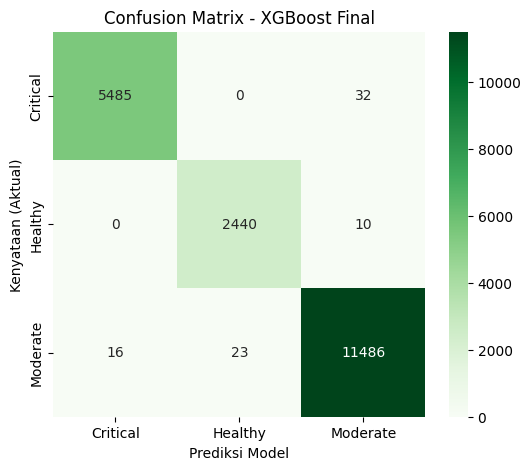

In [80]:
# --- 2. PENYEIMBANGAN DATA (SMOTE) ---
# Kita perbanyak data 'Healthy' dan 'Critical' agar setara dengan 'Moderate'
print(f"Data Latih Awal: {Counter(y_train)}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Data Latih Setelah SMOTE: {Counter(y_train_smote)}")
print("✅ Data sudah seimbang!\n")


# --- 3. TRAINING MODEL (XGBoost Juara) ---
print("🔄 Sedang melatih XGBoost dengan data SMOTE...")
start_time = time.time()

# Menggunakan parameter terbaik hasil tuning sebelumnya
final_model = XGBClassifier(
    n_estimators=200,       # Sedikit ditambah agar lebih mantap belajar data SMOTE
    learning_rate=0.1,
    max_depth=6,            # Kedalaman ideal untuk menangkap pola kompleks
    subsample=0.8,
    colsample_bytree=1.0,
    eval_metric='mlogloss',
    random_state=42
)

# Latih model
final_model.fit(X_train_smote, y_train_smote)

elapsed_time = time.time() - start_time
print(f"✅ Training Selesai dalam {elapsed_time:.2f} detik!\n")


# --- 4. EVALUASI AKHIR (Jujur-jujuran) ---
print("--- HASIL EVALUASI PADA DATA TEST (Data Asli/Tidak di-SMOTE) ---")
y_pred_final = final_model.predict(X_test_scaled)

# Print Report
print(classification_report(y_test, y_pred_final, target_names=le_zone.classes_))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Greens',
            xticklabels=le_zone.classes_, yticklabels=le_zone.classes_)
plt.title("Confusion Matrix - XGBoost Final")
plt.xlabel("Prediksi Model")
plt.ylabel("Kenyataan (Aktual)")
plt.show()

🔄 Menyiapkan Data untuk Prophet (Resampling Hourly)...
✅ Data Siap. Jumlah Baris: 8122
                   ds          y  Ventilation_Encoded
0 2024-02-18 08:00:00  35.425000                  1.0
1 2024-02-18 09:00:00  38.105833                  1.0
2 2024-02-18 10:00:00  36.817083                  1.0
3 2024-02-18 11:00:00  45.315000                  1.0
4 2024-02-18 12:00:00  30.836250                  1.0

🚀 Melatih Model Prophet...


/tmp/ipython-input-2964627902.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_prophet = df.resample('H').agg({
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


✅ Training Prophet Selesai!

📊 Melakukan Evaluasi (Backtesting 24 Jam)...


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


📉 Mean Absolute Error (MAE): 4.15 µg/m³
📉 Root Mean Squared Error (RMSE): 5.25 µg/m³


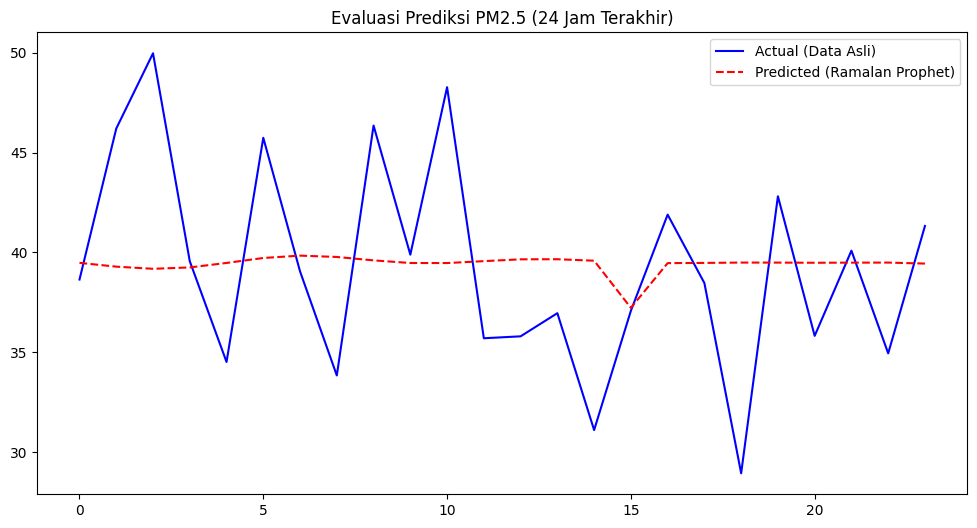

In [82]:
from prophet import Prophet
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. PERSIAPAN DATA PROPHET ---
print("🔄 Menyiapkan Data untuk Prophet (Resampling Hourly)...")

# Resampling ke per Jam (1H) - Khusus untuk Prophet
# Kita ambil rata-rata (mean) untuk semua sensor
# NOTE: kolom PM2.5 di dataset kita bernama 'PM2_5' (underscore), bukan 'PM2.5'
df_prophet = df.resample('H').agg({
    'PM2_5': 'mean',          # Target prediksi (y) - gunakan nama kolom yang benar
    'Ventilation_Encoded': 'max' # Regressor (status ventilasi, ambil max jika pernah buka)
}).reset_index()

# Format kolom harus: 'ds' (waktu) dan 'y' (target)
df_prophet = df_prophet.rename(columns={'Timestamp': 'ds', 'PM2_5': 'y'})

# Hapus data kosong (hasil resampling mungkin ada bolong)
df_prophet = df_prophet.dropna()

print(f"✅ Data Siap. Jumlah Baris: {len(df_prophet)}")
print(df_prophet.head())


# --- 2. TRAINING PROPHET ---
print("\n🚀 Melatih Model Prophet...")

# Inisialisasi Model
# changepoint_prior_scale=0.05: Agar model tidak terlalu liar (overfitting) mengikuti noise
m = Prophet(
    daily_seasonality=True,   # Pola harian (pagi vs malam)
    weekly_seasonality=True,  # Pola mingguan (senin vs minggu)
    changepoint_prior_scale=0.05
)

# Tambahkan Regressor (Ventilasi mempengaruhi PM2.5)
m.add_regressor('Ventilation_Encoded')

# Latih!
m.fit(df_prophet)
print("✅ Training Prophet Selesai!")


# --- 3. EVALUASI (Backtesting Sederhana) ---
# Kita coba prediksi 24 jam terakhir dari data latih untuk melihat seberapa akurat dia
print("\n📊 Melakukan Evaluasi (Backtesting 24 Jam)...")

# Ambil data 24 jam terakhir sebagai 'ground truth'
test_days = 24
train_data = df_prophet.iloc[:-test_days]
test_data = df_prophet.iloc[-test_days:]

# Latih ulang sebentar di data train saja (untuk tes fair)
m_eval = Prophet(daily_seasonality=True, weekly_seasonality=True, changepoint_prior_scale=0.05)
m_eval.add_regressor('Ventilation_Encoded')
m_eval.fit(train_data)

# Prediksi ke depan (ke masa test_data)
future_eval = m_eval.make_future_dataframe(periods=test_days, freq='H')

# Untuk regressor pada periode masa depan, isi dengan nilai yang masuk akal:
# kita gunakan nilai ventilasi sepanjang df_prophet (sesuai index ds) dan forward-fill jika perlu.
# Pastikan panjang cocok dengan future_eval
vent_series = df_prophet.set_index('ds')['Ventilation_Encoded']
vent_for_future = vent_series.reindex(future_eval['ds']).ffill().bfill().values
future_eval['Ventilation_Encoded'] = vent_for_future

forecast_eval = m_eval.predict(future_eval)

# Hitung Error
y_true = test_data['y'].values
y_pred = forecast_eval['yhat'].iloc[-test_days:].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"📉 Mean Absolute Error (MAE): {mae:.2f} µg/m³")
print(f"📉 Root Mean Squared Error (RMSE): {rmse:.2f} µg/m³")

# Plot Hasil
plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Actual (Data Asli)', color='blue')
plt.plot(y_pred, label='Predicted (Ramalan Prophet)', color='red', linestyle='--')
plt.title('Evaluasi Prediksi PM2.5 (24 Jam Terakhir)')
plt.legend()
plt.show()

In [83]:
import joblib
import os

print("💾 Memulai proses penyimpanan model...")

# Pastikan folder tujuan ada (opsional, default di root)
output_dir = "." 

# 1. Simpan Model Klasifikasi (XGBoost)
joblib.dump(final_model, os.path.join(output_dir, 'airthmind_model.pkl'))

# 2. Simpan Scaler (Untuk normalisasi input user)
joblib.dump(scaler, os.path.join(output_dir, 'airthmind_scaler.pkl'))

# 3. Simpan Label Encoder (Untuk translate 0,1,2 jadi teks)
joblib.dump(le_zone, os.path.join(output_dir, 'airthmind_le_zone.pkl'))

# 4. Simpan Model Prophet (Untuk prediksi tren)
joblib.dump(m, os.path.join(output_dir, 'airthmind_prophet_model.pkl'))

print("✅ SUKSES! 4 File berikut telah tersimpan dan SIAP DI-DOWNLOAD:")
print(f"   1. {os.path.abspath('airthmind_model.pkl')}")
print(f"   2. {os.path.abspath('airthmind_scaler.pkl')}")
print(f"   3. {os.path.abspath('airthmind_le_zone.pkl')}")
print(f"   4. {os.path.abspath('airthmind_prophet_model.pkl')}")

💾 Memulai proses penyimpanan model...
✅ SUKSES! 4 File berikut telah tersimpan dan SIAP DI-DOWNLOAD:
   1. /content/airthmind_model.pkl
   2. /content/airthmind_scaler.pkl
   3. /content/airthmind_le_zone.pkl
   4. /content/airthmind_prophet_model.pkl
